<a href="https://colab.research.google.com/github/Halace-cmd/RDL/blob/main/RDL_Ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning transformer for Document Classification on the AG_NEWS dataset

## Modell
Wir haben uns für das Modell *distilbert-base-uncased* (https://huggingface.co/distilbert/distilbert-base-uncased) entschieden, da es sicher hier um ein reines Encoder-Modell handelt, dass für die Klassifikation von Dokumenten gut geeignet ist, da dies auf Textverständnis und nicht dessen Generierung trainiert wurde. Gemäß der Aufgabenstellung sollen wir nicht all zu große Modelle verwenden, wo sich DistilBERT mit 67m Parameter gut eignet um die Trainingszeit im Rahmen zu halten.

## Dataset (ag_news)

Für dieses Projekt verwenden wir den ag_news Datensatz (https://huggingface.co/datasets/fancyzhx/ag_news). Dabei handelt es sich um eine Sammlung von mehr als 120.000 Nachrichtenartikeln, die als klassischer Benchmark für die Dokumentenklassifikation dient. Der Datensatz ist in vier gleichmäßig verteilte Kategorien unterteilt: World, Sports, Business und Sci/Tech. Die Daten bestehen hauptsächlich aus kurzen Titeln und prägnanten Zusammenfassung mit einer maximalen Länge von 147 Wörtern, worduch sich auch kleine Modelle eignen ohne dessen Kontext zu überfordern. Aufgrund der Größe das Datensatzes haben wir sich auf 5000 Trainings-, 2000 Test-, und 1000 Validation-Daten beschränkt und diese mit *stratified sampling* extrahiert um die Klassenverteilungen zu bewahren.

## Training-Prozess und Hyperparameter

Wir haben für das Fine-Tuning die Klasse *Trainer* von HuggingFace-Transformers verwendet um das generische BERT Modell auf unseren Datensatz anzupassen. Für die Evaluierung haben wir sowohl die Accuracy als auch den F1-Score verwendet. In einem manuellen Grid-Search haben wir verschiedene Kombinationen von Hyperparamter ausprobiert und dessen Auswirkung auf die Performance. Unter anderem haben wir die folgenden verwendet:

- **Learning Rate:** Rate der Anpassung für die Optimierung der Gewichte
- **Batch Size:** Anzahl der Trainingsdaten pro Step
- **Max Length:** Anzahl der Tokens, die das Modell verarbeitet. Hier werden zu lange Texte dann einfach abgeschnitten. Durch eine geringe maximale Länger wird allerdings das Training gut beschleunigt
- **Epochen:** Anzahl der Durchläufe des Training-Sets
- **Freeze:** Definiert ob die generischen Gewichte des BERT Modell mittrainiert werden, oder unverändert bleiben

Hier ist anzumerken, dass wir wie in der Angabe beschrieben ist leider nicht mit Parameter wie "top_k" usw. experementieren konnten, da es sich hier um einen reinen Encoder handelt. Deswegen haben wir mehr Zeit in das Fine-Tuning und die Hyperparameter gesteckt.

## Challanges and Solutions

Grundsätzlich gab es keine richtigen Probleme und alles hat recht gut funktioniert mit der HuggingFace library. Wir sind auch mit den Ergebnissen relativen zufrieden, obwohl man dies noch verbessern könnte. Das "nervige" an dem Prozess waren die begrenzten Ressourcen von Colab/unseren lokalen Rechnern um größere Modelle bzw. mehr Trainingsdaten zu verwenden, wodurch vermutlich die Performance noch gestiegen wäre.

## Results and Evaluation

Grundsätzlich ist die Performance über alle Variationen hinweg ziemlich ähnlich und auch recht gut. Allerdings verschlechtert das Einfrieren von den Gewichten die Performance was bedeutet das das reine Training vom Classification Head schlechter abschneidet als das ganze Modell anzupassen. Bei den Modellen mit veränderbaren Gewichten ist die Performance relative ähnlich, egal ob die anzahl der Epochen/Max Length/Batch Size oder die Learning Rate angepasst wurde. Von diesen Settings hat am Besten die Version mit dem vollen Kontext (256 tokens) und niedriger Learning Rate und Batch Size funktioniert. Interessanterweise ist bei unseren Evaluierungen der F1-Score und die Accuracy immer annähernd gleich, was auf die Gleichverteilung des AG_NEWS Datasets zurückzuführen ist, da hier keine Klasse benachteiligt wird. Prinzipiell liegt unsere Perfromance unter SOTA Modellen (die vermutlich ohne Constraints trainierten). Hier haben wir bespielsweise auf HuggingFace Modelle entdeckt die eine Accuracy von 94% aufweisen.

# Analyse vom Dataset

In [1]:
!pip install -q datasets transformers[torch]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
ag_news = load_dataset("ag_news")
ag_news.set_format(type="pandas")
df = ag_news['train'][:]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Hier ist zu sehen, dass es sich um kurze News-Ausschnite handelt und eine Klassifizierung in dessen Kategorie vorliegt

In [4]:
def label_int2str(row):
    return ag_news["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


Die Klassenverteilung der Labels ist über alle 4 Klassen die gleiche

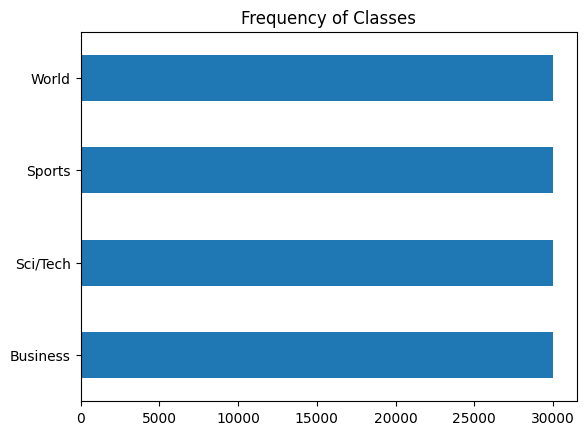

In [5]:
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.ylabel("")
plt.show()

Auch die Verteilung der Wortlänge über die verschiedenen Kategorien hinweg ist relativ ähnlich (Dadurch keine Benachteiligung von Kategorien wegen weniger Kontext)

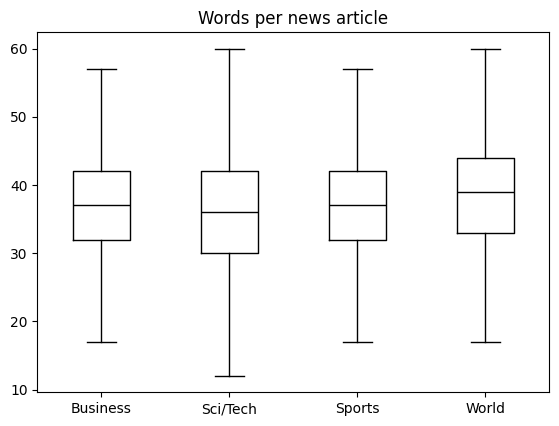

In [6]:
df["Words per news article"] = df["text"].str.split().apply(len)
df.boxplot("Words per news article", by="label_name", grid=False, showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

Um in den Constraints für die Aufgabe zu bleiben haben wir hier das Dataset redutziert in 5000 Trainings-, 2000 Test-, und 1000 Validierungsdaten.

In [7]:
ag_news.reset_format()

In [8]:
dataset_small = ag_news['train'].train_test_split(train_size=5000, test_size=3000, stratify_by_column='label', seed=42)
train = dataset_small['train']

test_val_split = dataset_small['test'].train_test_split(train_size=2000, test_size=1000, stratify_by_column='label', seed=42)
test = test_val_split['train']
val = test_val_split['test']

Wie in dem Plot zu sehen ist hat das Splitting auch die Klassenverteilungen bewahrt.

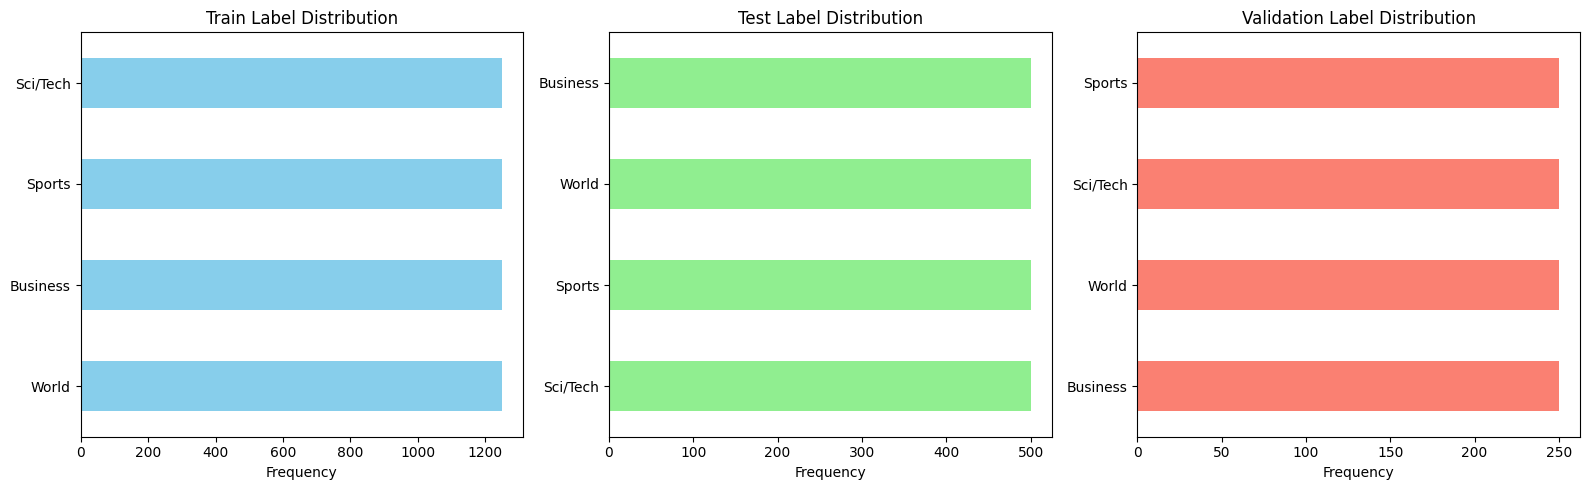

In [9]:
df_train = train.to_pandas()
df_val = val.to_pandas()
df_test = test.to_pandas()

df_train['label_name'] = df_train['label'].apply(label_int2str)
df_val['label_name'] = df_val['label'].apply(label_int2str)
df_test['label_name'] = df_test['label'].apply(label_int2str)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_train['label_name'].value_counts(ascending=True).plot.barh(ax=axes[0], color='skyblue')
axes[0].set_title('Train Label Distribution')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('')

df_test['label_name'].value_counts(ascending=True).plot.barh(ax=axes[1], color='lightgreen')
axes[1].set_title('Test Label Distribution')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('')

df_val['label_name'].value_counts(ascending=True).plot.barh(ax=axes[2], color='salmon')
axes[2].set_title('Validation Label Distribution')
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Des Weiteren ist auch die Verteilung der Wortlängen über allen Datensätzen hinweg die Gleiche

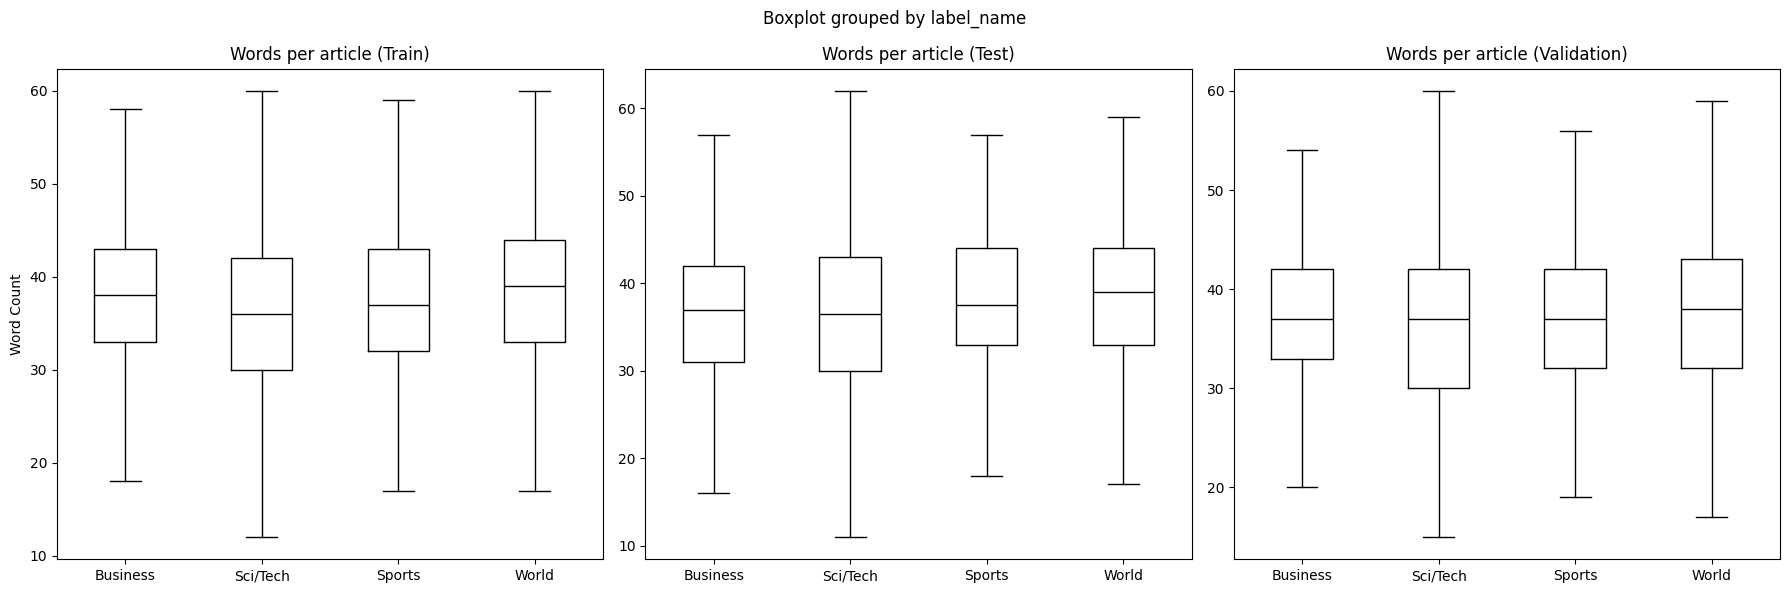

In [10]:
df_train["Words per article"] = df_train["text"].str.split().apply(len)
df_val["Words per article"] = df_val["text"].str.split().apply(len)
df_test["Words per article"] = df_test["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_train.boxplot("Words per article", by="label_name", grid=False, showfliers=False, ax=axes[0], color="black")
axes[0].set_title("Words per article (Train)")
axes[0].set_xlabel("")
axes[0].set_ylabel('Word Count')

df_test.boxplot("Words per article", by="label_name", grid=False, showfliers=False, ax=axes[1], color="black")
axes[1].set_title("Words per article (Test)")
axes[1].set_xlabel("")
axes[1].set_ylabel('')

df_val.boxplot("Words per article", by="label_name", grid=False, showfliers=False, ax=axes[2], color="black")
axes[2].set_title("Words per article (Validation)")
axes[2].set_xlabel("")
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Die maximale Anzahl an Wörtern in dem Dataset beträgt 147. Dadurch können wir den Context von unserem Transformer einschränken um das Training zu verschnellern und das unnötige Auffüllen zur gewünschten Vektor-Länge redutzieren.

In [11]:
print(f"Max words per dataset -> Train: {df_train['Words per article'].max()}, Val: {df_val['Words per article'].max()}, Test: {df_test['Words per article'].max()}")

Max words per dataset -> Train: 147, Val: 130, Test: 124


# Tokenization

Bevor wir mit dem Fine-Tuning beginnen können müssen wir die Datasets tokenizen um aus den Wörtern der News-Artikel Tokens zu erzeugen. Dafür verwenden wir die Huggingface-Library um den (fertigen) Tokenizer für unser verwendetes Modell zu laden.

In [12]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Nun können wir die Tokens für unsere Datasets erstellen. Dabei wird hier Subword-Tokenization verwendet mit folgenden Settings:
- *Max_Length = 256* gibt die größe der Vektoren an. Da unser Dataset maximal 147 Wörter besitzt, sollten sich 256 Tokens leicht ausgehen
- *Padding* füllt die nicht verwendeten Tokens mit "0" auf damit alle Vektoren die gleiche Länge haben
- *Truncation* schneidet Texte ab, die zu lange sind.

In [13]:
def tokenize(batch):
    return tokenizer(batch["text"], max_length=256, padding="max_length", truncation=True)

tokenized_train = train.map(tokenize, batched=True)
tokenized_test = test.map(tokenize, batched=True)
tokenized_val = val.map(tokenize, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Hier sehen wir ein Beispiel der Tokenization. Der Output nach dem Tokenizer enthält einerseits den Rohtext, sowie das Label und dann die vergebenen Token IDs und die Attentin Masks für die einzelnen Token. Hier ist zu beachten, dass ein Encoder immer alle anderen Token sehen darf. Daher ist die Attention Mask für alle Tokens 1, damit diese gesehen werden dürfen und 0 für das Padding (da hier keine Information steht)

In [14]:
tokenized_train

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})

In [16]:
example = tokenized_train[0]

print(example['text'])
print("\nToken IDs (input_ids)")
print(example['input_ids'][:10], "...", example['input_ids'][246:])
print("\nAttention Mask")
print(example['attention_mask'][:10], "..." ,example['attention_mask'][246:])
print("\n Length of IDs and Mask", len(example['input_ids']))

Air raids hit Philippines rebels Up to 10 people are killed in air strikes on rebels in the southern island of Mindanao.

Token IDs (input_ids)
[101, 2250, 11217, 2718, 5137, 8431, 2039, 2000, 2184, 2111] ... [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention Mask
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ... [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

 Length of IDs and Mask 256


Hier noch die Auflistung der IDs für die Spezial-Token die BERT verwendet

In [17]:
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


# Training und Fine Tuning

Anschließend ist der Code für die Evaluierungsmetriken und das Training/Fine-Tuning. Da dies schon am Beginn des Notebooks beschrieben wurde wird hier darauf verzichtet.




In [18]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [19]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer

experiment_grid = [
    {"name": "1. Baseline (128 Context)", "learning_rate": 2e-5, "batch_size": 16, "max_length": 128, "epochs": 3, "freeze": False},
    {"name": "2. Full Context (256 Context)", "learning_rate": 2e-5, "batch_size": 16, "max_length": 256, "epochs": 3, "freeze": False},
    {"name": "3. High LR + 128 Context", "learning_rate": 5e-5, "batch_size": 16, "max_length": 128, "epochs": 5, "freeze": False},
    {"name": "4. Large Batch + 128 Context", "learning_rate": 5e-5, "batch_size": 32, "max_length": 128, "epochs": 3, "freeze": False},
    {"name": "5. Max Batch + 64 Context", "learning_rate": 5e-5, "batch_size": 128, "max_length": 64, "epochs": 5, "freeze": False},
    {"name": "6. Frozen Baseline (128)", "learning_rate": 1e-3, "batch_size": 16, "max_length": 128, "epochs": 3, "freeze": True},
    {"name": "7. Frozen Full Context (256)", "learning_rate": 1e-3, "batch_size": 16, "max_length": 256, "epochs": 3, "freeze": True},
    {"name": "8. Frozen High LR (5e-3)", "learning_rate": 5e-3, "batch_size": 32, "max_length": 128, "epochs": 3, "freeze": True},
    {"name": "9. Frozen Max LR (1e-2)", "learning_rate": 1e-2, "batch_size": 32, "max_length": 64, "epochs": 3, "freeze": True},
    {"name": "10. Frozen Max Batch (128)", "learning_rate": 5e-3, "batch_size": 128, "max_length": 64, "epochs": 6, "freeze": True}
]

results = []
best_f1 = 0
best_model_path = "./best_model"

for config in experiment_grid:
    def dynamic_tokenize(examples): # Tokenization wird hier gemacht, da  manche Texte absichtlich truncated werden (zb bei max_length 64)
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=config['max_length'])

    tok_train = train.map(dynamic_tokenize, batched=True)
    tok_val = val.map(dynamic_tokenize, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=4,
        id2label={0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"},
        label2id={"World": 0, "Sports": 1, "Business": 2, "Sci/Tech": 3}
    )

    if config["freeze"]:
        for param in model.distilbert.parameters():
            param.requires_grad = False

    training_args = TrainingArguments(
        output_dir=f"./results_{config['name'].replace(' ', '_')}",
        learning_rate=config['learning_rate'],
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=config['batch_size'],
        num_train_epochs=config['epochs'],
        weight_decay=0.01,
        fp16=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tok_train,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_metrics = trainer.evaluate(eval_dataset=tok_val)

    current_f1 = eval_metrics["eval_f1"]
    if current_f1 > best_f1:
        best_f1 = current_f1
        trainer.save_model(best_model_path)

    results.append({
        "Experiment": config["name"],
        "LR": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Max Length": config["max_length"],
        "Val Accuracy": eval_metrics["eval_accuracy"],
        "Val F1": eval_metrics["eval_f1"]
    })

    del model, trainer
    torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
display(results_df.sort_values(by="Val F1", ascending=False))

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,Experiment,LR,Batch Size,Max Length,Val Accuracy,Val F1
1,2. Full Context (256 Context),0.00002,16,256,0.904,0.904182
2,3. High LR + 128 Context,0.00005,16,128,0.902,0.902374
0,1. Baseline (128 Context),0.00002,16,128,0.902,0.902072
4,5. Max Batch + 64 Context,0.00005,128,64,0.901,0.901266
3,4. Large Batch + 128 Context,0.00005,32,128,0.900,0.900051
9,10. Frozen Max Batch (128),0.00500,128,64,0.890,0.890080
6,7. Frozen Full Context (256),0.00100,16,256,0.889,0.888985
5,6. Frozen Baseline (128),0.00100,16,128,0.885,0.884941
7,8. Frozen High LR (5e-3),0.00500,32,128,0.884,0.884089
8,9. Frozen Max LR (1e-2),0.01000,32,64,0.882,0.882096


# Evaluation

Auf die Evaluierung wurde ebenfalls schon zu Beginn des Notebooks eingegangen, deswegen wird hier darauf verzichtet.

Unten im Plot sieht man eine Visualisierung der Performance-Metriken über alle verschiedene Settings

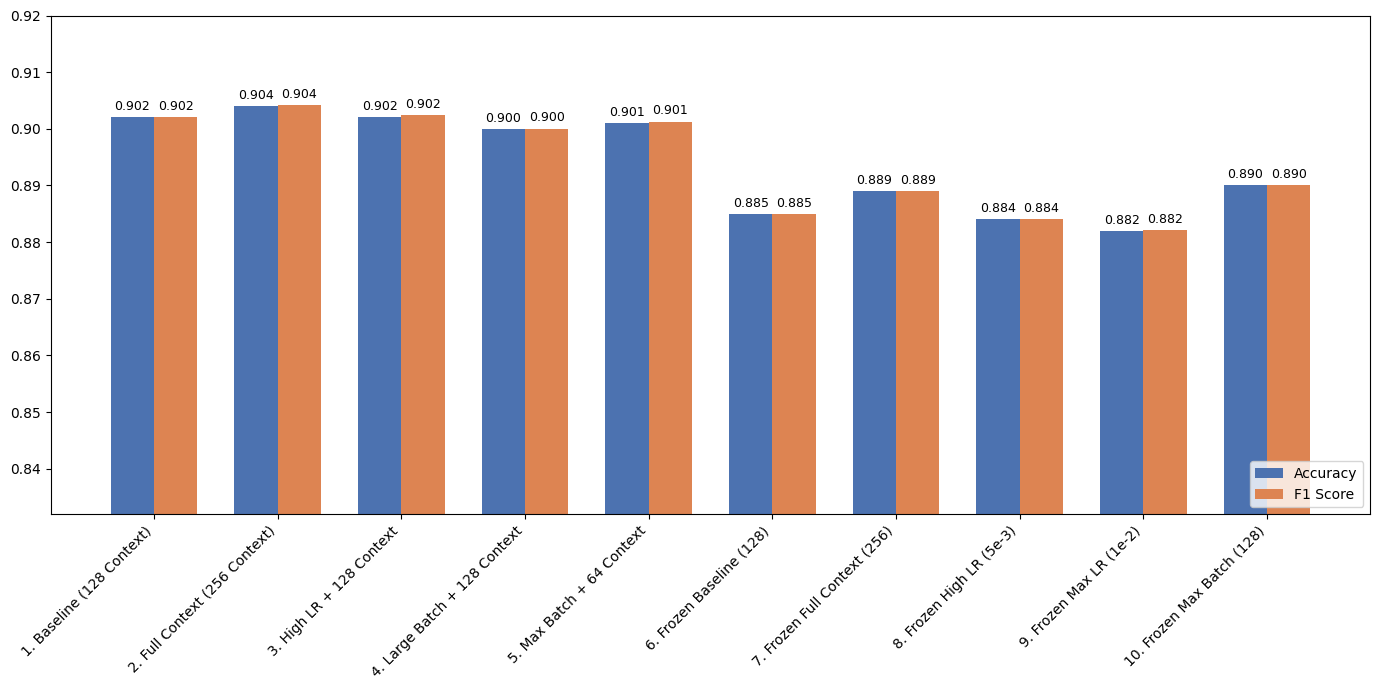

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(results_df['Experiment']))
width = 0.35
rects1 = ax.bar(x - width/2, results_df['Val Accuracy'], width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, results_df['Val F1'], width, label='F1 Score', color='#DD8452')
ax.set_ylabel('')
ax.set_title('')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Experiment'], rotation=45, ha='right')
ax.legend(loc='lower right')
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
autolabel(rects1)
autolabel(rects2)
min_val = results_df[['Val Accuracy', 'Val F1']].min().min()
plt.ylim(max(0, min_val - 0.05), 0.92)
plt.tight_layout()
plt.show()

## Cross Category Evaluation

In [21]:
best_model = AutoModelForSequenceClassification.from_pretrained("./best_model")
best_trainer = Trainer(model=best_model)

val_preds = best_trainer.predict(tok_val)
y_pred = np.argmax(val_preds.predictions, axis=-1)
y_true = val_preds.label_ids

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Hier sieht man die Confusion-Matrix für unser bestes Modell. Da der Großteil richtig Klassifiziert wird befinden sich auch die meisten Werte in der Diagonalen und generell sieht man keine richtige Benachteiligung, bzw schlechte Ergebnisse für bestimmte Klassen.

Am Besten wird die Kategorie "Sport" vom Modell verstanden, was eventuell darauf zurückzuführen ist, dass sich eben diese auch stärker von den Anderen Unterscheidet. Etwas Verwirrung herrscht zwischen den Kategorien "Business" und "Sci/Tech". Eventuell ist dies darauf zurückzuführen, dass Nachrichten im Thema "Sci/Tech" auch oft einen wirtschaftlichen Bezug haben.

              precision    recall  f1-score   support

       World       0.93      0.89      0.91       250
      Sports       0.97      0.97      0.97       250
    Business       0.86      0.88      0.87       250
    Sci/Tech       0.87      0.87      0.87       250

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



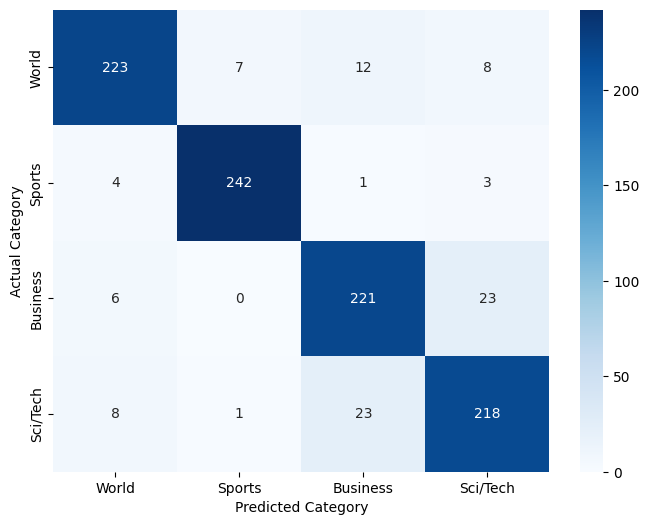

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

target_names = ["World", "Sports", "Business", "Sci/Tech"]
print(classification_report(y_true, y_pred, target_names=target_names))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("")
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

## Comparison mit Baseline metrics

Auf HuggingFace haben wir ein paar Modelle gefunden die leicht besser abschneiden als unseres und auf den gleichen Daten trainiert wurden. Z.b.:

- F1-Score von 0.911 mit QWEN (https://huggingface.co/cli08/qwen3-0.6-finetuned)
- Accuracy von 0.94 mit DistilBERT (https://huggingface.co/sushamarangarajan/ag-news-classifier)

Aber prinzipiell ist unsere Perfromance "nicht weit weg"

# Real World Examples

Abschließend testen wir noch das Modell auf kürzlichen Nachrichten. Hier haben wir als Quelle Nachricthen von *CNN* verwendet und auf dessen Website nach genau den Kategorien gefiltert, die auch in unseren Dataset vorkommen und jeweils ein Beispiel daraus gezogen. Von den Nachrichten haben wir jeweils die ersten paar Sätze hier hinein kopiert.

Science: https://edition.cnn.com/2026/03/17/science/little-red-dots-webb-telescope-photos

Business: https://edition.cnn.com/2026/03/18/business/consumer-interest-rates-inflation-unemployment-your-money

World: https://edition.cnn.com/world/live-news/iran-war-us-israel-trump-03-19-26

Sports: https://edition.cnn.com/2026/03/17/sport/iran-fifa-move-world-cup-games-mexico

In [23]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="./best_model",
    tokenizer=tokenizer,
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Wie hier zu sehen ist, hat auch die Klassifizierung von aktuellen Nachrichten recht gut funktioniert für die ersten 3 Texte (auch mit hoher Confidence). Der Letzte Artikel wurde trotz hoher Confidence leider falsch klassifiziert, obwohl hier definitiv ein Overlap zwischen World und Business herscht, da es um das Thema "Energy" geht.

In [27]:
science = "Webb telescope photos show mysterious little red dots. Astronomers don’t know what they are. Like tiny photobombers, cosmic anomalies resembling small, bright red points show up in almost every snapshot taken by the most powerful space telescope ever made. Astronomers now call them little red dots, or LRDs, but there is no agreement yet on what exactly they are."
business = "The Federal Reserve’s decision Wednesday to leave its key overnight lending rate unchanged for the second time this year was expected. But in addition to a disappointing February jobs report and other data, the Fed had to consider a new factor creating economic uncertainty: the attacks on Iran by the US and Israel, which have increased geopolitical stability and world oil prices – all of which point to potentially higher inflation and increased job losses if the conflict – and its domino effects – are protracted"
sport = "Iran’s soccer federation is in discussions with FIFA about moving their World Cup matches to Mexico from the United States due to concerns about the safety of their players, Iranian soccer president Mehdi Taj said on Monday."
world = "Attacks on energy sites: US President Donald Trump says he told Israel to halt attacks on Iranian energy resources, as Tehran retaliates with strikes on infrastructure in Israel and Qatar. The global oil benchmark hit $115 a barrel today."

actual_labels = ["Sci/Tech", "Business", "Sports", "World"]
test_news = [science, business, sport, world]

results = classifier(test_news)

print(f"{'ACTUAL':<12} | {'PREDICTION':<12} | {'CONFIDENCE':<10} | {'NEWS SNIPPET'}")
print("-" * 95)

for actual, text, pred in zip(actual_labels, test_news, results):
    label = pred['label']
    confidence = pred['score']

    print(f"{actual:<12} | {label:<12} | {confidence:>9.2%} | {text[:55]}...")

ACTUAL       | PREDICTION   | CONFIDENCE | NEWS SNIPPET
-----------------------------------------------------------------------------------------------
Sci/Tech     | Sci/Tech     |    98.21% | Webb telescope photos show mysterious little red dots. ...
Business     | Business     |    97.85% | The Federal Reserve’s decision Wednesday to leave its k...
Sports       | Sports       |    94.35% | Iran’s soccer federation is in discussions with FIFA ab...
World        | Business     |    91.24% | Attacks on energy sites: US President Donald Trump says...
